In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import os
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
import os

print(os.getcwd())

c:\Users\midhulamanne\OneDrive\Desktop\sentiment_proj\data


In [15]:
file_path = "data/training.1600000.processed.noemoticon.csv"

In [16]:
column_names = [
    "target",
    "ids",
    "date",
    "flag",
    "user",
    "text"
]

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None,
    names=column_names
)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (1600000, 6)


In [17]:

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()


Dataset Shape: (1600000, 6)

Column Names:
Index(['target', 'ids', 'date', 'flag', 'user', 'text'], dtype='str')

First 5 Rows:


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   target  1600000 non-null  int64
 1   ids     1600000 non-null  int64
 2   date    1600000 non-null  str  
 3   flag    1600000 non-null  str  
 4   user    1600000 non-null  str  
 5   text    1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 256.9 MB


In [18]:
print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nOriginal Sentiment Distribution:")
display(df["target"].value_counts())

Missing Values:


target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64


Duplicate Rows:
0

Original Sentiment Distribution:


target
0    800000
4    800000
Name: count, dtype: int64

In [19]:
df = df[["target", "text"]]

df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [20]:
df["target"] = df["target"].replace({
    0: 0,
    4: 1
})

print(df["target"].value_counts())

target
0    800000
1    800000
Name: count, dtype: int64


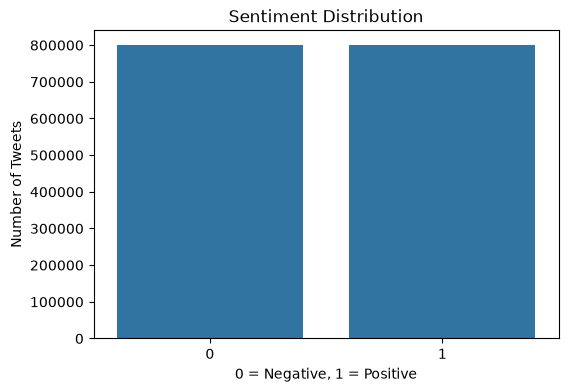

In [21]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target")

plt.title("Sentiment Distribution")
plt.xlabel("0 = Negative, 1 = Positive")
plt.ylabel("Number of Tweets")

plt.show()

In [22]:
print(df.isnull().sum())

df = df.dropna()

print("\nDataset shape after removing missing values:")
print(df.shape)

target    0
text      0
dtype: int64

Dataset shape after removing missing values:
(1600000, 2)


In [23]:
print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 16309
Duplicate rows after removal: 0


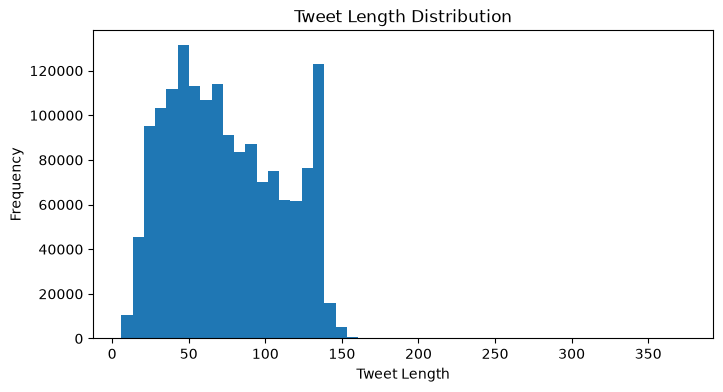

In [24]:
df["tweet_length"] = df["text"].apply(len)

plt.figure(figsize=(8, 4))

plt.hist(df["tweet_length"], bins=50)

plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()

In [25]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove Twitter mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [26]:
df["clean_text"] = df["text"].apply(clean_text)

display(df[["text", "clean_text"]].head())

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",a thats a bummer you shoulda got david carr of...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...


In [27]:
df = df[df["clean_text"].str.strip() != ""]

print("Dataset shape:", df.shape)

Dataset shape: (1580602, 4)


In [28]:
df_sample = df.sample(
    n=200000,
    random_state=42
)

print("Sample shape:", df_sample.shape)

print("\nSentiment Distribution:")
print(df_sample["target"].value_counts())

Sample shape: (200000, 4)

Sentiment Distribution:
target
1    100381
0     99619
Name: count, dtype: int64


In [29]:
X = df_sample["clean_text"]
y = df_sample["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (160000,)
Testing samples: (40000,)


In [30]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (160000, 50000)
Testing feature shape: (40000, 50000)


In [31]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(
    X_test_tfidf
)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.755975


In [32]:
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_predictions = lr_model.predict(
    X_test_tfidf
)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.76745


In [33]:
sgd_model = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    random_state=42
)

sgd_model.fit(
    X_train_tfidf,
    y_train
)

sgd_predictions = sgd_model.predict(
    X_test_tfidf
)

sgd_accuracy = accuracy_score(
    y_test,
    sgd_predictions
)

print("SGD Classifier Accuracy:", sgd_accuracy)

SGD Classifier Accuracy: 0.7554


In [34]:
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    print("\nMODEL:", model_name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [35]:
results = []

results.append(
    evaluate_model(
        "Naive Bayes",
        y_test,
        nb_predictions
    )
)

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_predictions
    )
)

results.append(
    evaluate_model(
        "SGD Classifier",
        y_test,
        sgd_predictions
    )
)


MODEL: Naive Bayes
Accuracy: 0.755975
Precision: 0.7552333349829267
Recall: 0.7601613867304244
F1 Score: 0.7576893478638632

MODEL: Logistic Regression
Accuracy: 0.76745
Precision: 0.759789737654321
Recall: 0.7847678820482168
F1 Score: 0.7720768401450554

MODEL: SGD Classifier
Accuracy: 0.7554
Precision: 0.7342924786013476
Recall: 0.803347280334728
F1 Score: 0.7672692673644148


In [36]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.755975,0.755233,0.760161,0.757689
1,Logistic Regression,0.767450,0.759790,0.784768,0.772077
2,SGD Classifier,0.755400,0.734292,0.803347,0.767269


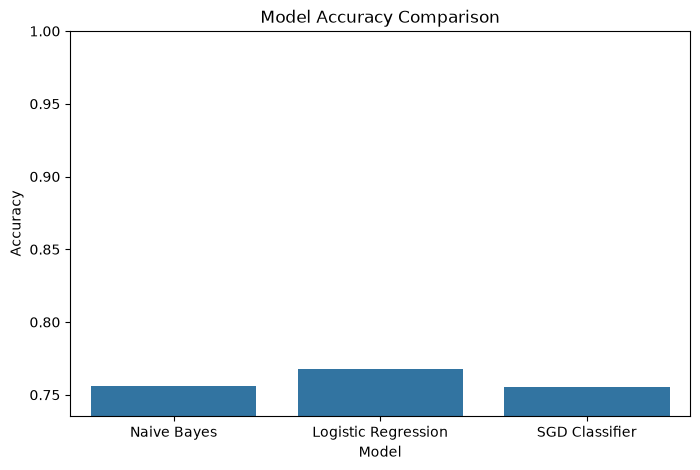

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.ylim(
    results_df["Accuracy"].min() - 0.02,
    1
)

plt.show()

In [ ]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [39]:
param_grid = {
    "C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train_tfidf,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

best_predictions = best_model.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        best_predictions
    )
)


Best Parameters:
{'C': 1}
              precision    recall  f1-score   support

           0       0.78      0.75      0.76     19924
           1       0.76      0.78      0.77     20076

    accuracy                           0.77     40000
   macro avg       0.77      0.77      0.77     40000
weighted avg       0.77      0.77      0.77     40000



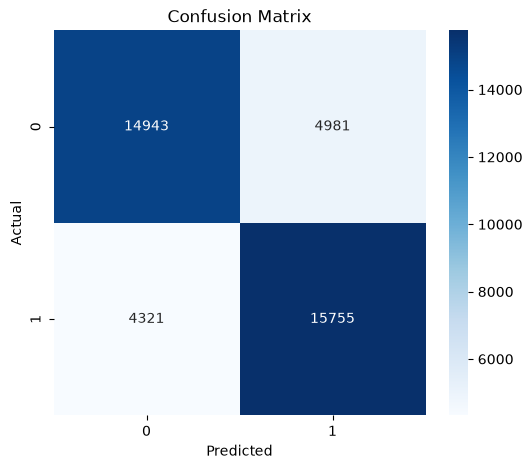

In [40]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [41]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/sentiment_model.pkl"
)

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [42]:
def predict_sentiment(tweet):

    cleaned_tweet = clean_text(tweet)

    tweet_vector = tfidf.transform(
        [cleaned_tweet]
    )

    prediction = best_model.predict(
        tweet_vector
    )[0]

    if prediction == 1:
        return "Positive "

    else:
        return "Negative "

In [43]:
new_tweets = [
    "I am extremely happy with this product!",
    "This is the worst experience ever.",
    "I love spending time with my friends.",
    "I am very disappointed with the service."
]

for tweet in new_tweets:

    print("Tweet:", tweet)

    print(
        "Predicted Sentiment:",
        predict_sentiment(tweet)
    )

    print("-" * 70)

Tweet: I am extremely happy with this product!
Predicted Sentiment: Positive 
----------------------------------------------------------------------
Tweet: This is the worst experience ever.
Predicted Sentiment: Negative 
----------------------------------------------------------------------
Tweet: I love spending time with my friends.
Predicted Sentiment: Positive 
----------------------------------------------------------------------
Tweet: I am very disappointed with the service.
Predicted Sentiment: Negative 
----------------------------------------------------------------------
